<a href="https://colab.research.google.com/github/jzazueta/data-science-business-econ/blob/main/notebooks/ch04_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Exploratory Data Analysis: The CSRVF Framework

**Data Science for Business and Economics: A Python Approach**

This notebook mirrors every Code Example in Chapter 4. The dataset is
synthetic but built to match every quantitative claim in the chapter
text, so all numbers and charts below will match the book exactly.

Run the cells top to bottom. The first cell builds the dataset --
no file upload or download is needed.

## Setup: Generate the Northstar Mobile Churn Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 7043

# -- customer_id --
customer_id = [f"NS-{i:05d}" for i in range(1, N + 1)]

# -- contract_type --
contract_type = rng.choice(
    ["Month-to-month", "One year", "Two year"],
    size=N, p=[0.55, 0.23, 0.22]
)

# -- tenure_months (right-skewed, capped at 36) --
tenure_months = rng.beta(1.0, 4.0, size=N) * 36
tenure_months = np.round(tenure_months).astype(int)
tenure_months = np.clip(tenure_months, 0, 36)
tenure_months = np.where(
    contract_type == "Two year",
    np.clip(tenure_months + rng.integers(2, 9, size=N), 0, 36),
    tenure_months
)
tenure_months = np.where(
    contract_type == "One year",
    np.clip(tenure_months + rng.integers(0, 5, size=N), 0, 36),
    tenure_months
)

# -- latent service tier (not exposed as a column) --
tier_base_prob = np.where(contract_type == "Month-to-month", 0.55, 0.20)
bundled = rng.random(N) > tier_base_prob

# -- monthly_charges (bimodal) --
monthly_charges = np.where(
    bundled,
    rng.normal(85, 10, size=N),
    rng.normal(20, 6, size=N),
)
monthly_charges = np.clip(monthly_charges, 18, 120).round(2)

# -- total_charges (correlated with tenure, with noise) --
noise = rng.normal(1.0, 0.03, size=N)
total_charges_num = (monthly_charges * tenure_months * noise).round(2)
total_charges_num = np.clip(total_charges_num, 0, None)
total_charges = np.where(tenure_months == 0, " ", total_charges_num.astype(str))

# -- contract_end_date --
start = pd.Timestamp("2023-07-01")
random_offsets = rng.integers(0, 365 * 2, size=N)
end_dates = start + pd.to_timedelta(random_offsets, unit="D")
contract_end_date = np.where(
    contract_type == "Month-to-month", None, end_dates.astype(str)
)

# -- payment_method --
payment_method = rng.choice(
    ["Electronic check", "Mailed check", "Bank transfer (automatic)",
     "Credit card (automatic)"],
    size=N, p=[0.34, 0.23, 0.22, 0.21]
)

# -- num_support_calls --
num_support_calls = rng.poisson(1.4, size=N).astype(float)
support_missing_mask = rng.random(N) < 0.04
num_support_calls[support_missing_mask] = np.nan

# -- demographic / service filler columns --
gender = rng.choice(["Male", "Female"], size=N)
senior_citizen = (rng.random(N) < 0.16).astype(int)
partner = rng.choice(["Yes", "No"], size=N, p=[0.48, 0.52])
dependents = rng.choice(["Yes", "No"], size=N, p=[0.30, 0.70])
phone_service = rng.choice(["Yes", "No"], size=N, p=[0.90, 0.10])
multiple_lines = np.where(
    phone_service == "No", "No phone service",
    rng.choice(["Yes", "No"], size=N)
)
internet_service = rng.choice(["Fiber optic", "DSL", "No"], size=N,
                               p=[0.44, 0.34, 0.22])
tech_support = np.where(
    internet_service == "No", "No internet service",
    rng.choice(["Yes", "No"], size=N)
)
streaming_tv = np.where(
    internet_service == "No", "No internet service",
    rng.choice(["Yes", "No"], size=N)
)
streaming_movies = np.where(
    internet_service == "No", "No internet service",
    rng.choice(["Yes", "No"], size=N)
)
online_backup = np.where(
    internet_service == "No", "No internet service",
    rng.choice(["Yes", "No"], size=N)
)
paperless_billing = rng.choice(["Yes", "No"], size=N, p=[0.59, 0.41])

# -- churn (the outcome) --
contract_effect = np.select(
    [contract_type == "Month-to-month",
     contract_type == "One year",
     contract_type == "Two year"],
    [0.70, -0.05, -0.55]
)
tenure_effect = -0.11 * tenure_months
is_month_to_month = contract_type == "Month-to-month"
is_echeck = payment_method == "Electronic check"
payment_interaction = np.where(is_month_to_month & is_echeck, 0.85, 0.0)
charges_effect = 0.004 * (monthly_charges - monthly_charges.mean())

logit = -0.4 + contract_effect + tenure_effect + payment_interaction + charges_effect
prob_churn = 1 / (1 + np.exp(-logit))
churned = (rng.random(N) < prob_churn).astype(int)

# -- assemble dataframe --
churn = pd.DataFrame({
    "customer_id": customer_id,
    "gender": gender,
    "senior_citizen": senior_citizen,
    "partner": partner,
    "dependents": dependents,
    "tenure_months": tenure_months,
    "phone_service": phone_service,
    "multiple_lines": multiple_lines,
    "internet_service": internet_service,
    "online_backup": online_backup,
    "tech_support": tech_support,
    "streaming_tv": streaming_tv,
    "streaming_movies": streaming_movies,
    "contract_type": contract_type,
    "paperless_billing": paperless_billing,
    "payment_method": payment_method,
    "monthly_charges": monthly_charges,
    "total_charges": total_charges,
    "contract_end_date": contract_end_date,
    "num_support_calls": num_support_calls,
    "churned": churned,
})

churn.to_csv("northstar_churn.csv", index=False)
print("Dataset saved:", churn.shape)

Dataset saved: (7043, 21)


In [2]:
# From here on, every cell matches a Code Example in the book exactly,
# starting from a fresh read of the CSV -- just like a reader would.
churn = pd.read_csv("northstar_churn.csv")

## 4.1 Why Explore Before You Model

Lena Ortiz has been asked for a churn model. Before fitting anything,
she needs to understand what the data represents, what shape it is
in, what each variable looks like, how variables relate to each
other, and what all of that suggests about what to build next --
**C**ontext, **S**tructure, **V**ariables, **R**elations, **F**eatures
(CSRVF). The five stages are a scaffold, not a checklist: a finding
in *Relations* routinely sends the analyst back to *Structure*.

## 4.2 Context

**Code Example 4.1 — Churn rate by contract type.** A first
visualization, before any deeper exploration, to ground the scale of
the problem.

> Every chart in this chapter is deliberately plain: default colors,
> no titles, no decoration beyond axis labels and a caption. EDA
> charts are working tools an analyst produces by the dozen while
> still figuring out what the data is saying -- the goal is speed and
> honesty, not polish.

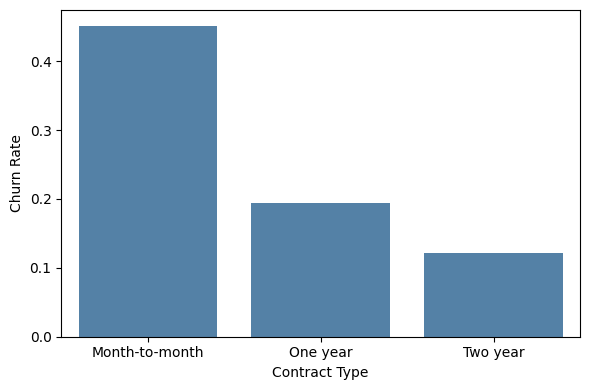

In [3]:
churn_by_contract = churn.groupby("contract_type")["churned"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values,
            color="#4682B4", ax=ax)
ax.set_ylabel("Churn Rate")
ax.set_xlabel("Contract Type")
plt.tight_layout()
plt.show()

## 4.3 Structure

**Code Example 4.2 — A first structural pass over the churn dataset.**

In [4]:
print(churn.shape)
print(churn.dtypes)
print(churn.isnull().sum())

(7043, 21)
customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure_months          int64
phone_service         object
multiple_lines        object
internet_service      object
online_backup         object
tech_support          object
streaming_tv          object
streaming_movies      object
contract_type         object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges         object
contract_end_date     object
num_support_calls    float64
churned                int64
dtype: object
customer_id             0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_backup           0
tech_support            0
streaming_tv            0
streaming_movies        0
contract_type           0
pa

**Code Example 4.3 — Visualizing missing-value counts across all
columns.** A quick chart makes the same point faster than reading
down a column of numbers.

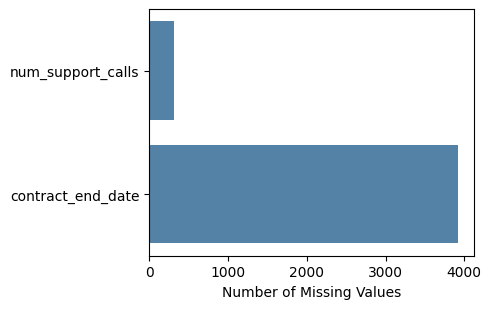

In [5]:
missing_counts = churn.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values()

fig, ax = plt.subplots(figsize=(5, 3.2))
sns.barplot(x=missing_counts.values, y=missing_counts.index,
            color="#4682B4", ax=ax, orient="h")
ax.set_xlabel("Number of Missing Values")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

> **When a Number Is Not a Number.** A numeric column loading as text
> almost always means at least one value cannot be parsed as a
> number -- often a blank string, a stray space, or a placeholder
> like `"unknown"`. Pandas treats the entire column as text rather
> than silently dropping the offending values, which is safer, but
> means the analyst must investigate before converting.

**Code Example 4.4 — Locating non-numeric values in a column that
should be numeric.**

In [6]:
non_numeric = churn[
    pd.to_numeric(churn["total_charges"], errors="coerce").isnull()
]
print(non_numeric[["customer_id", "tenure_months", "total_charges"]])

     customer_id  tenure_months total_charges
26      NS-00027              0              
59      NS-00060              0              
60      NS-00061              0              
73      NS-00074              0              
114     NS-00115              0              
...          ...            ...           ...
6727    NS-06728              0              
6797    NS-06798              0              
6865    NS-06866              0              
6938    NS-06939              0              
7036    NS-07037              0              

[220 rows x 3 columns]


**Code Example 4.5 — Checking whether missingness in one column
relates to another.**

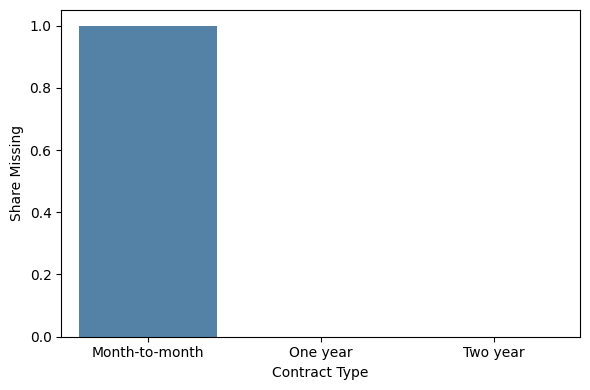

In [7]:
missing_by_contract = (
    churn.groupby("contract_type")["contract_end_date"]
    .apply(lambda x: x.isnull().mean())
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=missing_by_contract.index, y=missing_by_contract.values,
            color="#4682B4", ax=ax)
ax.set_ylabel("Share Missing")
ax.set_xlabel("Contract Type")
plt.tight_layout()
plt.show()

**Code Example 4.6 — Verifying one row per customer.**

In [8]:
print(churn["customer_id"].duplicated().sum())
print(churn.duplicated().sum())

0
0


## 4.4 Variables

**Code Example 4.7 — Summary statistics for a numeric variable.**

In [9]:
print(churn["monthly_charges"].describe())

count    7043.000000
mean       60.317617
std        31.984594
min        18.000000
25%        21.940000
50%        75.990000
75%        87.295000
max       120.000000
Name: monthly_charges, dtype: float64


**Code Example 4.8 — Distribution of monthly charges.**

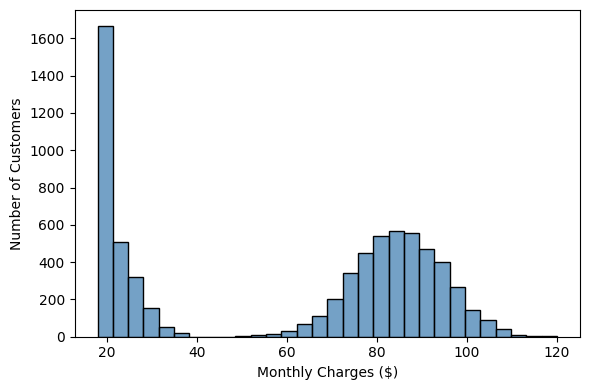

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(churn["monthly_charges"], bins=30, color="#4682B4", ax=ax)
ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

> **Why the Mean Can Mislead.** A mean is a single number standing in
> for an entire distribution. When that distribution has more than
> one mode, the mean describes a point where relatively few customers
> actually sit.

**Code Example 4.9 — Distribution of customer tenure.**

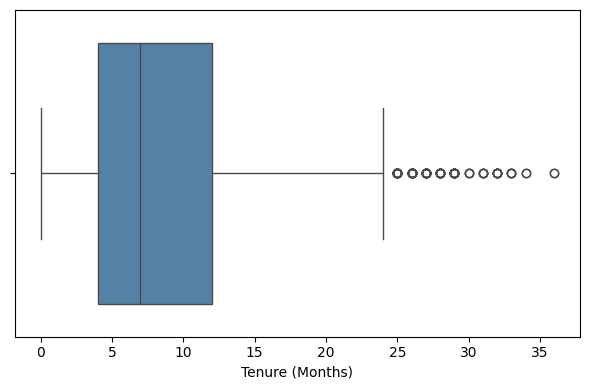

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=churn["tenure_months"], color="#4682B4", ax=ax)
ax.set_xlabel("Tenure (Months)")
plt.tight_layout()
plt.show()

**Code Example 4.10 — Frequency table for a categorical variable.**

In [12]:
print(churn["contract_type"].value_counts(normalize=True))

contract_type
Month-to-month    0.556723
One year          0.229022
Two year          0.214255
Name: proportion, dtype: float64


**Code Example 4.11 — Distribution of payment method.**

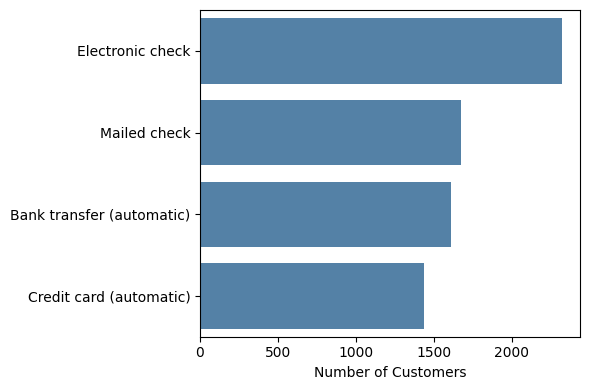

In [13]:
counts = churn["payment_method"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.values, y=counts.index, color="#4682B4",
            ax=ax, orient="h")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4.5 Relations

**Code Example 4.12 — Pairwise correlation among numeric variables.**
`total_charges` is converted to numeric here, resolving the Structure-
stage finding: the blank-space rows become legitimately zero.

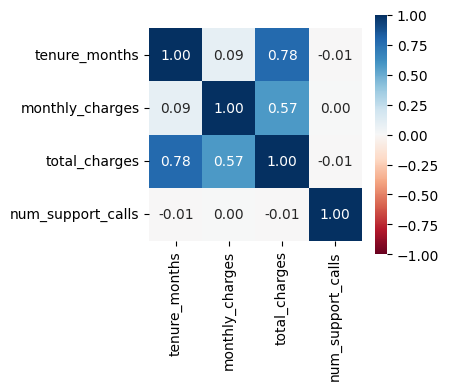

In [14]:
# total_charges was resolved back in Structure: convert it,
# treating the blank-space rows as legitimately zero.
churn["total_charges"] = pd.to_numeric(
    churn["total_charges"], errors="coerce"
).fillna(0)

num_cols = ["tenure_months", "monthly_charges",
            "total_charges", "num_support_calls"]

corr = churn[num_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu",
            vmin=-1, vmax=1, square=True, ax=ax)
plt.tight_layout()
plt.show()

> **Pearson and Spearman Correlation.** For $n$ paired observations
> $(x_i, y_i)$, the Pearson correlation coefficient is
>
> $$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}
>      {\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2 \cdot \sum_{i=1}^n (y_i - \bar{y})^2}}
>      = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}$$
>
> It takes values in $[-1, 1]$ and measures only *linear* association.
> The Spearman rank correlation $\rho$ applies the same formula to the
> ranks of $X$ and $Y$, making it robust to outliers and able to
> detect any monotone relationship.

**Code Example 4.13 — Dispersion plot of tenure against total
charges.** A heatmap gives the coefficient; it does not show what
produces it.

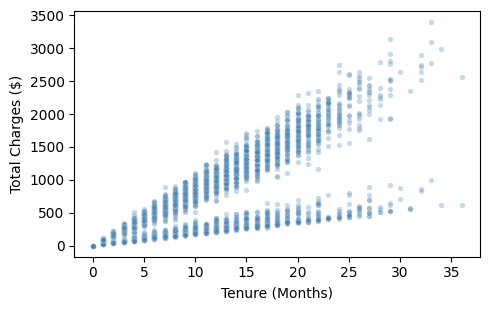

In [15]:
fig, ax = plt.subplots(figsize=(5, 3.2))
sns.scatterplot(data=churn, x="tenure_months", y="total_charges",
                 color="#4682B4", alpha=0.3, s=15, ax=ax)
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Total Charges ($)")
plt.tight_layout()
plt.show()

**Code Example 4.14 — Monthly charges by contract type.**

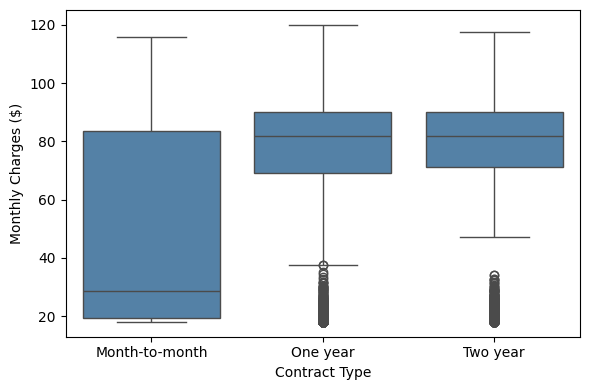

In [16]:
order = ["Month-to-month", "One year", "Two year"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=churn, x="contract_type", y="monthly_charges",
            order=order, color="#4682B4", ax=ax)
ax.set_ylabel("Monthly Charges ($)")
ax.set_xlabel("Contract Type")
plt.tight_layout()
plt.show()

**Code Example 4.15 — Tenure distribution by churn status.**

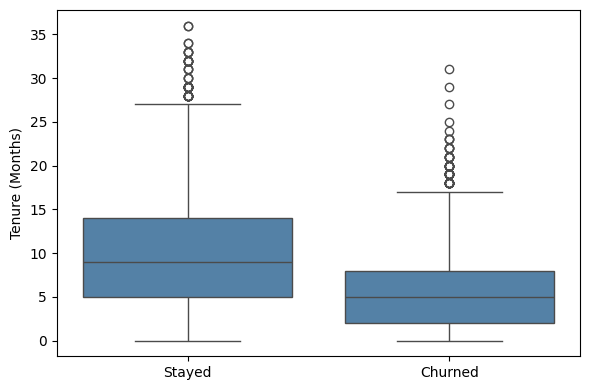

In [17]:
churn["churn_label"] = churn["churned"].map({0: "Stayed", 1: "Churned"})

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=churn, x="churn_label", y="tenure_months",
            color="#4682B4", ax=ax)
ax.set_ylabel("Tenure (Months)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Code Example 4.16 — Churn rate by contract type and payment
method.**

In [18]:
pivot = pd.crosstab(churn["contract_type"], churn["payment_method"],
                     values=churn["churned"], aggfunc="mean")
pivot = pivot.reindex(["Month-to-month", "One year", "Two year"])
print(pivot.round(2))

payment_method  Bank transfer (automatic)  Credit card (automatic)  \
contract_type                                                        
Month-to-month                       0.38                     0.38   
One year                             0.20                     0.20   
Two year                             0.12                     0.11   

payment_method  Electronic check  Mailed check  
contract_type                                   
Month-to-month              0.57          0.41  
One year                    0.19          0.19  
Two year                    0.12          0.13  


**Code Example 4.17 — Heatmap of the contract-by-payment
interaction.** A table makes the numbers available; it does not make
the interaction *visible*.

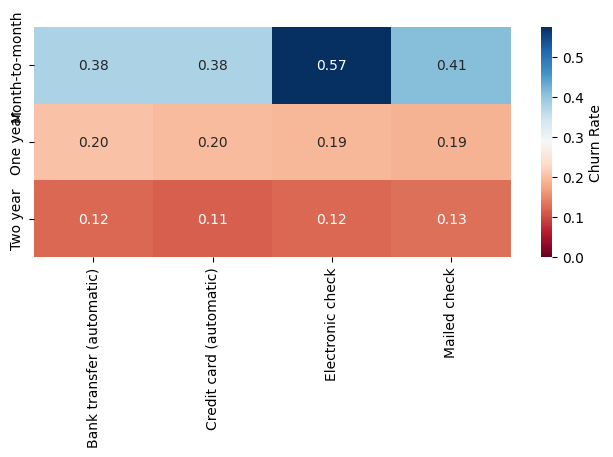

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu",
            vmin=0, vmax=pivot.values.max(), ax=ax,
            cbar_kws={"label": "Churn Rate"}, yticklabels=True)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4.6 Features

Three findings from *Relations* are strong enough to carry forward as
near-certain candidates for the churn model:

- **Tenure.** Churn concentrates heavily in a customer's first twelve
  months.
- **Contract type.** Month-to-month customers churn at several times
  the rate of annual-contract customers -- the single strongest
  relationship found.
- **Payment method, conditionally.** Electronic check predicts
  elevated churn, but only within the month-to-month segment.

`total_charges` is excluded: it is almost perfectly explained by
tenure, so including both would add redundancy without information.

> **A Candidate Is Not a Commitment.** Nothing here has been tested
> against held-out data or checked for confounding. "Strong candidate"
> is a claim about what EDA has surfaced, not what will survive
> formal estimation.

`monthly_charges`' bimodal distribution was only **partially**
explained by contract type -- a real gap, not a loose end to paper
over. The data likely encodes a service-tier distinction (single
service versus bundled) that is not yet its own column.

> **EDA Does Not Owe a Tidy Story.** Exploratory analysis owes an
> honest account of what is known, suspected, and still missing -- a
> model built on a falsely tidy account of the data is more dangerous
> than one built on an explicitly incomplete one.

## 4.7 Summary, Exercises, and Bibliographic Notes

### Summary

The CSRVF framework structured Lena's work in five stages. *Context*
established what the data represents and surfaced a churn-label
definition broader than the business problem it was meant to answer.
*Structure* confirmed the data's shape, types, and granularity, and
showed that missingness in `contract_end_date` was structural rather
than random. *Variables* surfaced a bimodal distribution in
`monthly_charges` that no later stage fully resolved. *Relations*
established tenure and contract type as strong candidates and
uncovered a conditional effect of payment method. *Features*
translated those findings into a short working list for the modeling
chapters ahead, while being explicit about what remains unresolved.

### Exercises

Run each cell after writing your answer (markdown) or code, as
appropriate.

**Exercise 1 (Context).** Northstar's data dictionary lists
`senior_citizen` as a binary flag. Before using it in any analysis,
what three questions would you ask about how this flag is defined and
collected?

*Your answer:*

In [20]:
# Exercise 1 -- write your answer as a comment, or use this cell
# for any exploratory code that supports it.

**Exercise 2 (Structure).** Suppose 4% of rows in
`num_support_calls` are missing, and the missingness rate is
identical across every customer segment you check. Does this support
treating the missingness as random? What additional check would
strengthen or weaken that conclusion?

*Your answer:*

In [21]:
# Exercise 2

**Exercise 3 (Variables).** Using the churn dataset, produce a
frequency table for `internet_service` and a histogram for
`num_support_calls`. Does either distribution suggest a transformation
or grouping before it is used in a model?

In [22]:
# Exercise 3

**Exercise 4 (Relations).** The chapter found that payment method's
effect on churn is conditional on contract type. Propose one other
pair of variables in the dataset that might interact in a similar
way, and describe the analysis you would run to check it.

In [23]:
# Exercise 4

**Exercise 5 (Features).** Write Lena's working list as it would
appear in a one-paragraph email to the VP of Customer Retention,
assuming the VP has no background in data analysis.

*Your answer:*

In [24]:
# Exercise 5

### Bibliographic Notes

The foundational reference for exploratory data analysis remains
Tukey's own treatment (Tukey, 1977), which predates the modern Python
ecosystem entirely but whose central argument -- that understanding
data is itself analysis, not a preliminary to it -- motivates this
chapter's structure.